# Stage 3.01　延伸講義 + 可重跑計算本
## 荷載組合 · Demand · 斜率撓度 · 剪力彎矩圖 · P–M · RC 預覽

延伸 Stage 3，把本對話中的手算、圖面與練習一次收進 **可執行 notebook**。

**執行後會產出圖檔**
- `frame_VM_C1.png` / `frame_VM_C3.png` — 剪力與彎矩圖
- `frame_M_elevation_C1.png` — 立面彎矩圖
- `column_PM.png` — 柱 P–M 互制圖

**相依**：numpy, matplotlib, sympy, openseespy；自動下載 `rc_design.py`。

## 0. 環境

In [1]:
import sys, os, math
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

try:
    import openseespy.opensees as ops
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'numpy<2.5', 'openseespy'])
    import openseespy.opensees as ops

try:
    import sympy as sp
except ImportError:
    import subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'sympy'])
    import sympy as sp

if not os.path.exists('rc_design.py'):
    os.system('wget -q -O rc_design.py https://raw.githubusercontent.com/zhixiu0223/taiwan-seismic-code-calc/main/rc_design.py')
from rc_design import design_rebar, design_column_PM

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.unicode_minus'] = False
print('OK')

OK


## 1. 幾何與勁度折減

In [2]:
L, h1, h2 = 6.0, 3.5, 3.5
E_rc = 2.463e7
h_col, b_beam, h_beam = 0.40, 0.30, 0.50
Ig_col = h_col**4 / 12
Ig_beam = b_beam * h_beam**3 / 12
A_col, A_beam = h_col**2, b_beam * h_beam
I_col_eff = 0.70 * Ig_col
I_beam_eff = 0.35 * Ig_beam
print(f'柱 0.7Ig={I_col_eff:.6f} m^4, 梁 0.35Ig={I_beam_eff:.6f} m^4')

柱 0.7Ig=0.001493 m^4, 梁 0.35Ig=0.001094 m^4


## 2. 重力載重 D / L

In [3]:
trib_width = 18.0 / 4
gamma_conc, t_slab, D_finish, L_area = 2400.0, 0.15, 100.0, 300.0
D_area = t_slab * gamma_conc + D_finish
kgf_to_kN = 9.80665e-3
D_udl = (D_area * trib_width + b_beam * h_beam * gamma_conc) * kgf_to_kN
L_udl = (L_area * trib_width) * kgf_to_kN
col_self_kN_m = (h_col**2 * gamma_conc) * kgf_to_kN
print(f'D_udl={D_udl:.3f}, L_udl={L_udl:.3f}, D+L={D_udl+L_udl:.3f} kN/m')
print(f'柱自重={col_self_kN_m:.3f} kN/m')

D_udl=23.830, L_udl=13.239, D+L=37.069 kN/m
柱自重=3.766 kN/m


## 3. 荷載組合

In [4]:
F1_frame, F2_frame = 9.938, 15.900
COMBOS = [
    ('C1', 1.4, 1.7, 0.0),
    ('C2', 1.05, 0.0, +1.403),
    ('C3', 1.05, 0.0, -1.403),
    ('C4', 0.9, 0.0, +1.40),
    ('C5', 0.9, 0.0, -1.40),
    ('C6', 0.9, 0.0, 0.0),
]
for c in COMBOS:
    print(c)

('C1', 1.4, 1.7, 0.0)
('C2', 1.05, 0.0, 1.403)
('C3', 1.05, 0.0, -1.403)
('C4', 0.9, 0.0, 1.4)
('C5', 0.9, 0.0, -1.4)
('C6', 0.9, 0.0, 0.0)


## 4. OpenSees + Governing Demand

In [5]:
def extract_NVM(ele_id, vertical):
    f = ops.eleForce(ele_id)
    if vertical:
        return dict(Ni=f[1], Vi=f[0], Mi=f[2], Nj=f[4], Vj=f[3], Mj=f[5])
    return dict(Ni=f[0], Vi=f[1], Mi=f[2], Nj=f[3], Vj=f[4], Mj=f[5])

def run_combo(Df, Lf, Ef, include_col_self=True):
    w = Df * D_udl + Lf * L_udl
    F1, F2 = Ef * F1_frame, Ef * F2_frame
    w_col = (Df * col_self_kN_m) if include_col_self else 0.0
    ops.wipe()
    ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.node(1, 0.0, 0.0); ops.node(2, L, 0.0)
    ops.node(3, 0.0, h1); ops.node(4, L, h1)
    ops.node(5, 0.0, h1+h2); ops.node(6, L, h1+h2)
    ops.node(7, L/2, h1); ops.node(8, L/2, h1+h2)
    ops.fix(1,1,1,1); ops.fix(2,1,1,1)
    ops.geomTransf('Linear', 1)
    specs = [
        (1,1,3,A_col,I_col_eff),(2,2,4,A_col,I_col_eff),
        (3,3,5,A_col,I_col_eff),(4,4,6,A_col,I_col_eff),
        (5,3,7,A_beam,I_beam_eff),(6,7,4,A_beam,I_beam_eff),
        (7,5,8,A_beam,I_beam_eff),(8,8,6,A_beam,I_beam_eff),
    ]
    for eid,n1,n2,A,I in specs:
        ops.element('elasticBeamColumn', eid, n1, n2, A, E_rc, I, 1)
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    if F1: ops.load(3, F1, 0.0, 0.0)
    if F2: ops.load(5, F2, 0.0, 0.0)
    if w:
        for eid in [5,6,7,8]:
            ops.eleLoad('-ele', eid, '-type', '-beamUniform', -w)
    if w_col:
        for eid in [1,2,3,4]:
            ops.eleLoad('-ele', eid, '-type', '-beamUniform', 0.0, -w_col)
    ops.system('BandGeneral'); ops.numberer('RCM'); ops.constraints('Transformation')
    ops.test('NormDispIncr', 1e-10, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 1.0); ops.analysis('Static')
    assert ops.analyze(1) == 0
    return dict(
        w=w, F1=F1, F2=F2,
        col1F_L=extract_NVM(1, True), col1F_R=extract_NVM(2, True),
        col2F_L=extract_NVM(3, True), col2F_R=extract_NVM(4, True),
        beam1F=extract_NVM(5, False), beamRF=extract_NVM(7, False),
        u3=ops.nodeDisp(3,1), u5=ops.nodeDisp(5,1),
    )

records = []
for name, Df, Lf, Ef in COMBOS:
    r = run_combo(Df, Lf, Ef)
    for member in ['col1F_L','col1F_R','col2F_L','col2F_R','beam1F','beamRF']:
        records.append(dict(combo=name, member=member, **r[member]))

by_member = defaultdict(list)
for rec in records:
    by_member[rec['member']].append(rec)

def governing(recs):
    best = {}
    for end, keys in [('i', ('Ni','Vi','Mi')), ('j', ('Nj','Vj','Mj'))]:
        for key, label in zip(keys, ('N','V','M')):
            gov = max(recs, key=lambda r: abs(r[key]))
            best[f'{label}_{end}'] = (gov[key], gov['combo'])
    return best

governing_table = {}
print(f"{'構件':<10}{'量':<6}{'值':>12}{'combo':>8}")
for member, recs in by_member.items():
    g = governing(recs)
    governing_table[member] = g
    for k,(val,combo) in g.items():
        print(f'{member:<10}{k:<6}{val:>12.3f}{combo:>8}')

構件        量                值   combo
col1F_L   N_i        372.115      C1
col1F_L   V_i         27.792      C3
col1F_L   M_i        -56.432      C3
col1F_L   N_j       -353.663      C1
col1F_L   V_j        -27.792      C3
col1F_L   M_j        -49.972      C1
col1F_R   N_i        372.115      C1
col1F_R   V_i        -27.735      C2
col1F_R   M_i         56.298      C2
col1F_R   N_j       -353.663      C1
col1F_R   V_j         27.735      C2
col1F_R   M_j         49.972      C1
col2F_L   N_i        186.058      C1
col2F_L   V_i         71.211      C1
col2F_L   M_i       -107.113      C1
col2F_L   N_j       -167.605      C1
col2F_L   V_j        -71.211      C1
col2F_L   M_j       -142.126      C1
col2F_R   N_i        186.058      C1
col2F_R   V_i        -71.211      C1
col2F_R   M_i        107.113      C1
col2F_R   N_j       -167.605      C1
col2F_R   V_j         71.211      C1
col2F_R   M_j        142.126      C1
beam1F    N_i        -49.691      C1
beam1F    V_i        167.605      C1
b

## 5. 剪力圖與彎矩圖

土木慣例：梁 $M>0$ 為跨中下側受拉；$V>0$ 左端向上。

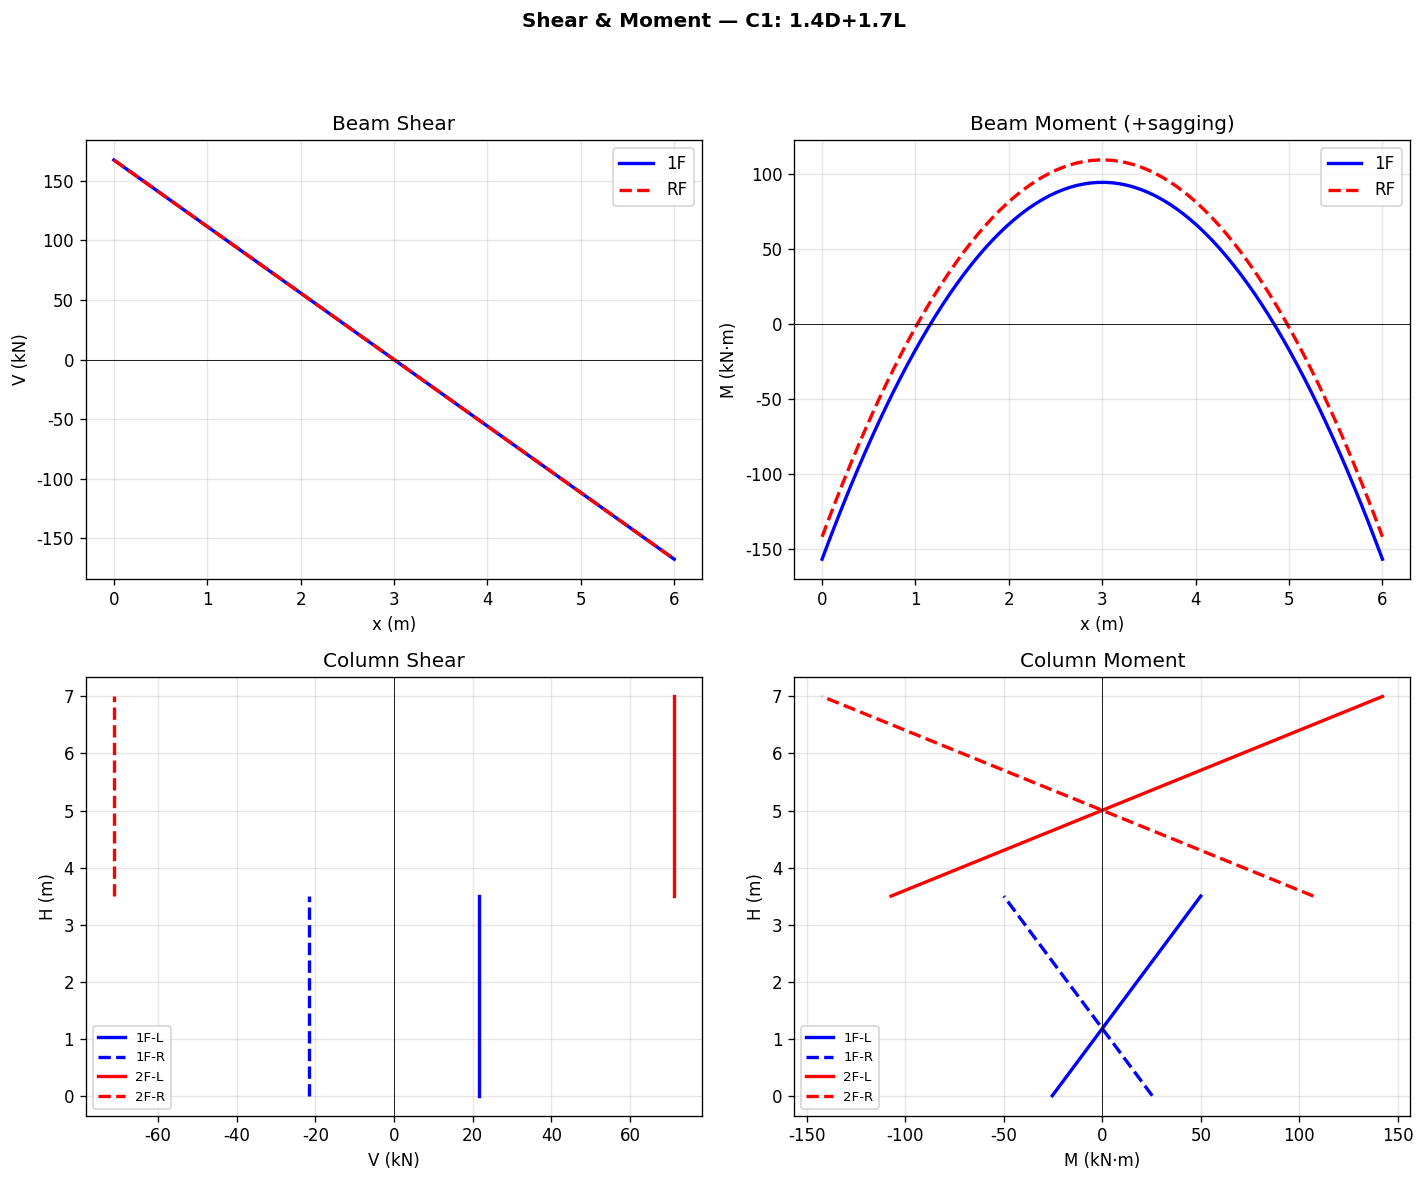

Saved frame_VM_C1.png | 1F M_end=-157.09, M_mid=94.28


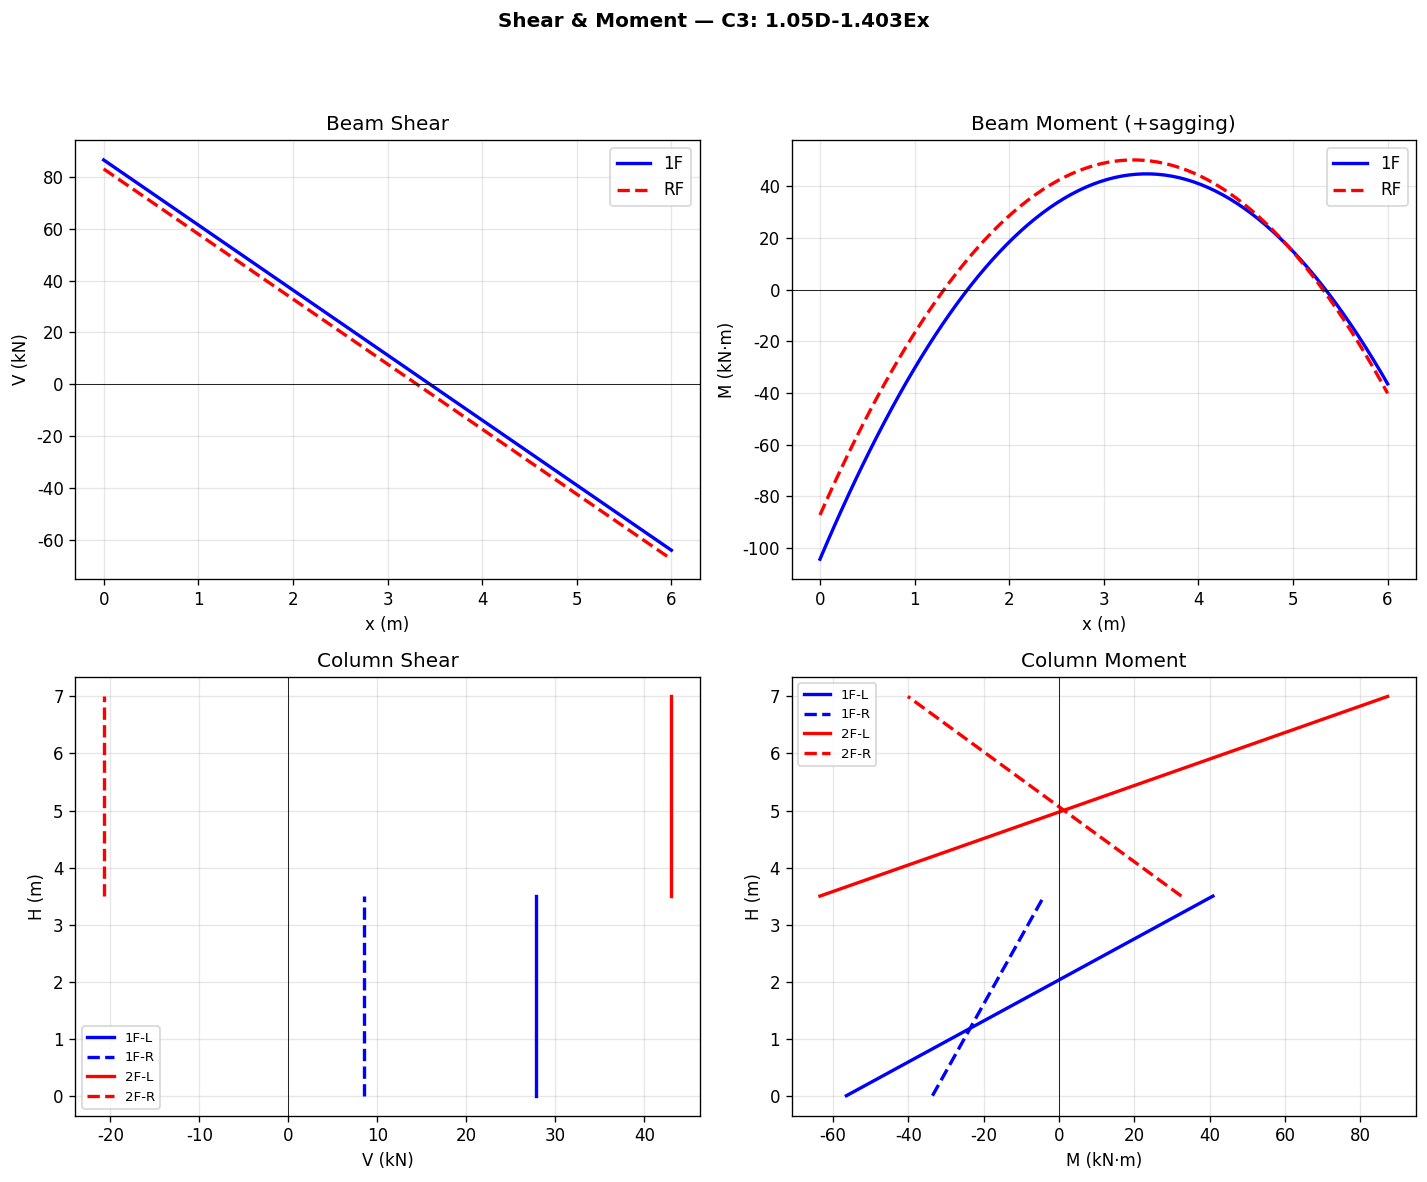

Saved frame_VM_C3.png | 1F M_end=-104.29, M_mid=42.64


In [6]:
def beam_VM_civil(w, n=80):
    fL = ops.eleForce(5)
    V0, M0 = fL[1], -fL[2]
    xs = np.linspace(0, L, n)
    V = V0 - w * xs
    M = M0 + V0 * xs - w * xs**2 / 2
    return xs, V, M

def roof_VM_civil(w, n=80):
    fL = ops.eleForce(7)
    V0, M0 = fL[1], -fL[2]
    xs = np.linspace(0, L, n)
    return xs, V0 - w*xs, M0 + V0*xs - w*xs**2/2

def col_VM(eid, H, y0=0.0, n=40):
    f = ops.eleForce(eid)
    Vb, Mb = f[0], f[2]
    s = np.linspace(0, H, n)
    return y0+s, np.full_like(s, Vb), Mb + Vb*s

def plot_VM(tag, Df, Lf, Ef, path):
    r = run_combo(Df, Lf, Ef)
    w = r['w']
    x, Vb, Mb = beam_VM_civil(w)
    _, Vr, Mr = roof_VM_civil(w)
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Shear & Moment — {tag}', fontsize=12, fontweight='bold')
    axes[0,0].plot(x, Vb, 'b-', lw=2, label='1F'); axes[0,0].plot(x, Vr, 'r--', lw=2, label='RF')
    axes[0,0].axhline(0, color='k', lw=0.5); axes[0,0].set_title('Beam Shear'); axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
    axes[0,0].set_xlabel('x (m)'); axes[0,0].set_ylabel('V (kN)')
    axes[0,1].plot(x, Mb, 'b-', lw=2, label='1F'); axes[0,1].plot(x, Mr, 'r--', lw=2, label='RF')
    axes[0,1].axhline(0, color='k', lw=0.5); axes[0,1].set_title('Beam Moment (+sagging)'); axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
    axes[0,1].set_xlabel('x (m)'); axes[0,1].set_ylabel('M (kN·m)')
    for name, eid, H, y0, sty in [
        ('1F-L',1,h1,0,'b-'),('1F-R',2,h1,0,'b--'),
        ('2F-L',3,h2,h1,'r-'),('2F-R',4,h2,h1,'r--')]:
        y, V, M = col_VM(eid, H, y0)
        axes[1,0].plot(V, y, sty, lw=2, label=name)
        axes[1,1].plot(M, y, sty, lw=2, label=name)
    axes[1,0].axvline(0,color='k',lw=0.5); axes[1,0].set_title('Column Shear'); axes[1,0].legend(fontsize=8); axes[1,0].grid(True,alpha=0.3)
    axes[1,1].axvline(0,color='k',lw=0.5); axes[1,1].set_title('Column Moment'); axes[1,1].legend(fontsize=8); axes[1,1].grid(True,alpha=0.3)
    axes[1,0].set_xlabel('V (kN)'); axes[1,0].set_ylabel('H (m)')
    axes[1,1].set_xlabel('M (kN·m)'); axes[1,1].set_ylabel('H (m)')
    plt.tight_layout(rect=[0,0,1,0.94])
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved {path} | 1F M_end={Mb[0]:.2f}, M_mid={Mb[len(Mb)//2]:.2f}')

plot_VM('C1: 1.4D+1.7L', 1.4, 1.7, 0.0, 'frame_VM_C1.png')
plot_VM('C3: 1.05D-1.403Ex', 1.05, 0.0, -1.403, 'frame_VM_C3.png')

### 5.1 立面彎矩圖 C1

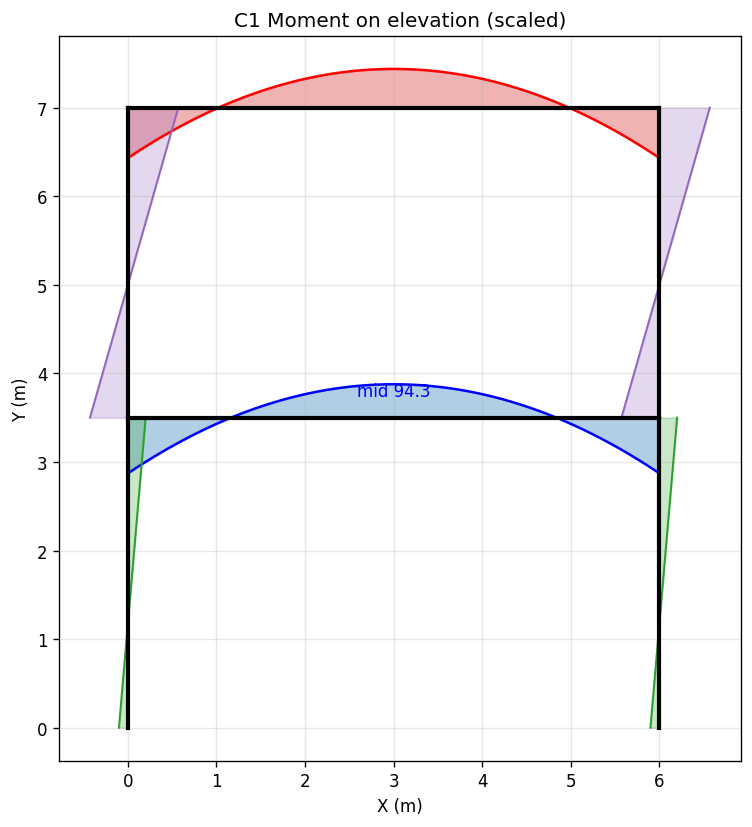

In [7]:
r = run_combo(1.4, 1.7, 0.0)
w = r['w']
x, _, M1 = beam_VM_civil(w)
_, _, Mr = roof_VM_civil(w)
fig, ax = plt.subplots(figsize=(10, 7))
for a,b in [((0,0),(0,h1)),((0,h1),(0,h1+h2)),((L,0),(L,h1)),((L,h1),(L,h1+h2)),((0,h1),(L,h1)),((0,h1+h2),(L,h1+h2))]:
    ax.plot([a[0],b[0]],[a[1],b[1]],'k-',lw=2.5,zorder=5)
sm = 0.004
ax.fill_between(x, h1, h1+M1*sm, alpha=0.35, color='C0')
ax.plot(x, h1+M1*sm, 'b-', lw=1.5)
ax.fill_between(x, h1+h2, h1+h2+Mr*sm, alpha=0.35, color='C3')
ax.plot(x, h1+h2+Mr*sm, 'r-', lw=1.5)
for eid,y0,sign,col in [(1,0,1,'C2'),(2,0,-1,'C2'),(3,h1,1,'C4'),(4,h1,-1,'C4')]:
    y,V,M = col_VM(eid, h1 if y0==0 else h2, y0)
    base = 0.0 if sign>0 else L
    xx = base + sign*M*sm
    ax.fill_betweenx(y, base, xx, alpha=0.25, color=col)
    ax.plot(xx, y, color=col, lw=1.2)
ax.set_aspect('equal'); ax.set_title('C1 Moment on elevation (scaled)')
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)'); ax.grid(True, alpha=0.3)
ax.text(L/2, h1+0.25, f'mid {M1[len(M1)//2]:.1f}', ha='center', color='b')
plt.tight_layout()
plt.savefig('frame_M_elevation_C1.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 柱 P–M 互制圖（ρ=0.02 試排）

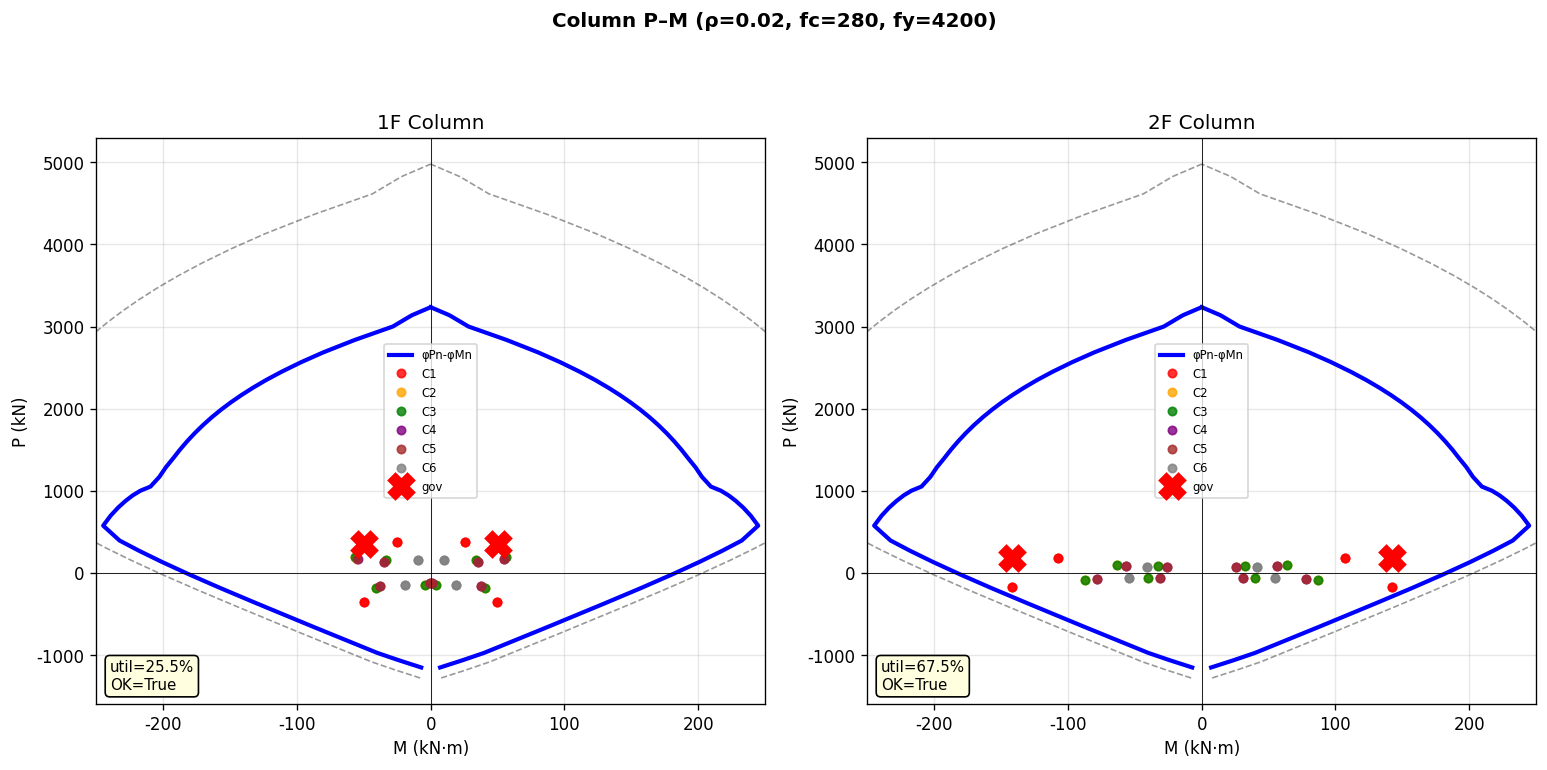

1F util=25.5%, 2F util=67.5%


In [8]:
b_col_cm = h_col_cm = 40.0
fc, fy = 280.0, 4200.0
As_total = 0.02 * b_col_cm * h_col_cm
As_bar = As_total / 8
As_layers = [3*As_bar, 2*As_bar, 3*As_bar]
cover_to_center = 4.0 + 0.95 + 1.4/2

res_1F = design_column_PM(b_cm=b_col_cm, h_cm=h_col_cm, As_per_layer_cm2=As_layers,
    cover_to_center_cm=cover_to_center, n_layers=3, fc=fc, fy=fy, Pu_kN=353.7, Mu_kNm=50.0)
res_2F = design_column_PM(b_cm=b_col_cm, h_cm=h_col_cm, As_per_layer_cm2=As_layers,
    cover_to_center_cm=cover_to_center, n_layers=3, fc=fc, fy=fy, Pu_kN=186.1, Mu_kNm=142.1)

curve = res_1F['curve']
phiPn = np.array([p['phiPn'] for p in curve])
phiMn = np.array([p['phiMn'] for p in curve])
Pn = np.array([p['Pn'] for p in curve])
Mn = np.array([p['Mn'] for p in curve])
order = np.argsort(Pn)

demands_1F, demands_2F = [], []
for name, Df, Lf, Ef in COMBOS:
    rr = run_combo(Df, Lf, Ef)
    for side in ['col1F_L','col1F_R']:
        f = rr[side]
        demands_1F += [(f['Ni'], abs(f['Mi']), name), (f['Nj'], abs(f['Mj']), name)]
    for side in ['col2F_L','col2F_R']:
        f = rr[side]
        demands_2F += [(f['Ni'], abs(f['Mi']), name), (f['Nj'], abs(f['Mj']), name)]

colors = dict(C1='red',C2='orange',C3='green',C4='purple',C5='brown',C6='gray')
fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
for ax, dems, title, key, res in [
    (axes[0], demands_1F, '1F Column', (353.7, 50.0), res_1F),
    (axes[1], demands_2F, '2F Column', (186.1, 142.1), res_2F),
]:
    ax.plot(Mn[order], Pn[order], 'k--', lw=1, alpha=0.4)
    ax.plot(-Mn[order], Pn[order], 'k--', lw=1, alpha=0.4)
    ax.plot(phiMn[order], phiPn[order], 'b-', lw=2.5, label='φPn-φMn')
    ax.plot(-phiMn[order], phiPn[order], 'b-', lw=2.5)
    seen=set()
    for P,M,c in dems:
        ax.plot(M, P, 'o', color=colors[c], ms=5, alpha=0.8, label=c if c not in seen else None)
        ax.plot(-M, P, 'o', color=colors[c], ms=5, alpha=0.8)
        seen.add(c)
    ax.plot(key[1], key[0], 'X', color='red', ms=14, mew=2, label='gov')
    ax.plot(-key[1], key[0], 'X', color='red', ms=14, mew=2)
    ax.axhline(0,color='k',lw=0.5); ax.axvline(0,color='k',lw=0.5)
    ax.set_xlabel('M (kN·m)'); ax.set_ylabel('P (kN)'); ax.set_title(title)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=7); ax.set_xlim(-250,250)
    ax.text(0.02,0.02, f'util={res["utilization"]:.1%}\nOK={res["within_envelope"]}',
            transform=ax.transAxes, va='bottom', fontsize=9,
            bbox=dict(boxstyle='round', fc='lightyellow'))
fig.suptitle('Column P–M (ρ=0.02, fc=280, fy=4200)', fontweight='bold')
plt.tight_layout(rect=[0,0,1,0.92])
plt.savefig('column_PM.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'1F util={res_1F["utilization"]:.1%}, 2F util={res_2F["utilization"]:.1%}')

## 7. 無側移斜率撓度（SymPy）

$$M_{34}=\dfrac{M_F S_c(5S_b+7S_c)}{S_b^2+6S_b S_c+7S_c^2}$$

In [9]:
Sc_s, Sb_s, MF_s = sp.symbols('S_c S_b M_F', positive=True)
th3, th5 = sp.symbols('theta_3 theta_5')
eq1 = sp.Eq((8*Sc_s+2*Sb_s)*th3 + 2*Sc_s*th5, -MF_s)
eq2 = sp.Eq(2*Sc_s*th3 + (4*Sc_s+2*Sb_s)*th5, -MF_s)
sol = sp.solve([eq1, eq2], [th3, th5])
M34_sym = sp.simplify(MF_s + 2*Sb_s*sol[th3])
print('M34 ='); sp.pprint(M34_sym)

Sc_n = E_rc * I_col_eff / h1
Sb_n = E_rc * I_beam_eff / L
w_c1 = 1.4*D_udl + 1.7*L_udl
MF_n = w_c1 * L**2 / 12
sub = {Sc_s: Sc_n, Sb_s: Sb_n, MF_s: MF_n}
M34_n = float(M34_sym.subs(sub))
M_mid_n = w_c1*L**2/8 - abs(M34_n)
print(f'Sc={Sc_n:.2f}, Sb={Sb_n:.2f}, MF={MF_n:.3f}')
print(f'θ3={float(sol[th3].subs(sub)):.6e}, θ5={float(sol[th5].subs(sub)):.6e}')
print(f'M34={M34_n:.3f} kN·m (OS 157.09), M_mid={M_mid_n:.3f} (OS 94.28)')

M34 =


 M_F⋅S_c⋅(5⋅S_b + 7⋅S_c) 
─────────────────────────
   2                    2
S_b  + 6⋅S_b⋅S_c + 7⋅S_c 
Sc=10508.80, Sb=4489.84, MF=167.605
θ3=-1.167822e-03, θ5=-2.804292e-03
M34=157.119 kN·m (OS 157.09), M_mid=94.289 (OS 94.28)


## 8. 有側移 6×6 系統（C3 側移驗證）

In [10]:
Sc,Sb,MF,h,F1,F2 = sp.symbols('S_c S_b M_F h F1 F2', real=True)
th3,th4,th5,th6,psi1,psi2 = sp.symbols('theta_3 theta_4 theta_5 theta_6 psi_1 psi_2')
M13=2*Sc*th3-6*Sc*psi1; M31=4*Sc*th3-6*Sc*psi1
M24=2*Sc*th4-6*Sc*psi1; M42=4*Sc*th4-6*Sc*psi1
M35=4*Sc*th3+2*Sc*th5-6*Sc*psi2; M53=4*Sc*th5+2*Sc*th3-6*Sc*psi2
M46=4*Sc*th4+2*Sc*th6-6*Sc*psi2; M64=4*Sc*th6+2*Sc*th4-6*Sc*psi2
M34=MF+4*Sb*th3+2*Sb*th4; M43=-MF+4*Sb*th4+2*Sb*th3
M56=MF+4*Sb*th5+2*Sb*th6; M65=-MF+4*Sb*th6+2*Sb*th5
eqs=[M31+M35+M34, M42+M46+M43, M53+M56, M64+M65,
     (M13+M31+M24+M42)/h+(F1+F2), (M35+M53+M46+M64)/h+F2]
A_sym,b_sym = sp.linear_eq_to_matrix(eqs, [th3,th4,th5,th6,psi1,psi2])

w3=1.05*D_udl; MF3=w3*L**2/12
F1n,F2n=-1.403*F1_frame,-1.403*F2_frame
sub={Sc:Sc_n,Sb:Sb_n,MF:MF3,h:h1,F1:F1n,F2:F2n}
xn=np.linalg.solve(np.array(A_sym.subs(sub).tolist(),float),
                   np.array(b_sym.subs(sub).tolist(),float).ravel())
print('C3 SD: Δ1={:.2f} mm, Δroof={:.2f} mm'.format(xn[4]*h1*1000,(xn[4]+xn[5])*h1*1000))
r3=run_combo(1.05,0.0,-1.403,include_col_self=False)
print('OpenSees: u3={:.2f} mm, u5={:.2f} mm'.format(r3['u3']*1000,r3['u5']*1000))

sub0={Sc:Sc_n,Sb:Sb_n,MF:MF_n,h:h1,F1:0.0,F2:0.0}
x0=np.linalg.solve(np.array(A_sym.subs(sub0).tolist(),float),
                   np.array(b_sym.subs(sub0).tolist(),float).ravel())
print('C1 check ψ1={:.2e}, ψ2={:.2e} (expect ~0)'.format(x0[4],x0[5]))

C3 SD: Δ1=-3.97 mm, Δroof=-8.79 mm
OpenSees: u3=-4.00 mm, u5=-8.80 mm
C1 check ψ1=1.42e-19, ψ2=1.30e-19 (expect ~0)


## 9. RC 預覽：梁 φMn 與箍筋

In [11]:
Mu_beam = abs(governing_table['beam1F']['M_i'][0])
res_beam = design_rebar(Mu_kNm=Mu_beam, b_cm=30.0, h_cm=50.0, fc=280.0, fy=4200.0)
print(f'Mu={Mu_beam:.2f} kN·m')
print(f"bars={res_beam['n_bars']}-{res_beam['bar_size']}, As={res_beam['As_provided']:.3f} cm2")
print(f"Mn={res_beam['Mn']:.2f}, phiMn={res_beam['phiMn_provided']:.2f}, util={res_beam['utilization']:.1%}")

Vu = abs(governing_table['beam1F']['V_i'][0])
b_cm, d_cm = 30.0, res_beam['d']
Av = 2*0.713
Vc = 0.53*math.sqrt(280)*b_cm*d_cm*kgf_to_kN
Vs = Vu/0.75 - Vc
s_calc = (Av*4200*d_cm)/(Vs/kgf_to_kN)
s_use = min(s_calc, d_cm/2, 60)
s_use = max(5, int(s_use//5)*5)
print(f'Vu={Vu:.2f}, Vc={Vc:.2f}, Vs={Vs:.2f} kN → s={s_use} cm (#3 2-leg)')

Mu=157.09 kN·m
bars=4-#6(D19), As=11.460 cm2
Mn=190.83, phiMn=171.75, util=91.5%
Vu=167.61, Vc=114.28, Vs=109.19 kN → s=20 cm (#3 2-leg)


## 10. 練習題短解摘要

| 題 | 答案要點 |
|----|----------|
| 1 組合 | $w_u=55.87$ kN/m；governing 不可硬湊 |
| 2 無側移 SD | $M_{34}=157.12$, $M_{mid}=94.29$ |
| 3 有側移 | 6 未知；層剪力平衡；$F=0\Rightarrow\psi=0$ |
| 4 梁 | $\phi M_n\approx171.7>157.1$，util≈91.5% |
| 5 柱 | 1F≈25.5%，2F≈67.5%，2F 較臨界 |
| 6 箍筋 | $s=20$ cm |

完整評分版講義：`Stage3_Lecture_and_Exercises.pdf`

## 11. 小結

**本 notebook 已涵蓋對話內容**：載重、組合、demand、V/M 圖、P–M 圖、無/有側移斜率撓度、梁柱設計預覽、練習題答案。

**尚未納入正式設計**：迭代配筋、強柱弱梁、capacity shear、3D。

執行全部 cell 後工作目錄會有：
`frame_VM_C1.png`, `frame_VM_C3.png`, `frame_M_elevation_C1.png`, `column_PM.png`